In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## Session 06a

## Multiple Hidden Layers
Multiple layers allow the network to learn hierarchical transformations of input features.

<img src='../../prasami_images/prasami_color_tutorials_small.png' style = 'width:400px;' alt="By Pramod Sharma : pramod.sharma@prasami.com" align="left"/>

In [2]:
###-----------------
### Import Libraries
###-----------------

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# Some basic parameters

inpDir = Path('../../../input') # location where input data is stored
outDir = Path('../output') # location to store outputs

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
rng = np.random.default_rng(seed=RANDOM_STATE) # # Set Random Seed for reproducible  results

EPOCHS = 2001 # number of cycles to run
ALPHA = 0.1 # learning rate
NUM_SAMPLES = 1280 # How many samples we want to generate 
NOISE = 0.2 # Noise to be introduced in the data
EPSILON = 1e-15
TEST_SIZE = 0.2

# Set parameters for decoration of plots
params = {'legend.fontsize': 'large',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }
CMAP = plt.cm.coolwarm

plt.rcParams.update(params) # update rcParams

## Helper Functions

In [4]:
###-----------------------------------
### Function to plot Decision boundary
###-----------------------------------
# NOTE: Works only for 2D input features.
def fn_plot_decision_boundary(model: dict, X_tr: np.ndarray, y_tr: np.ndarray, X_ts :  np.ndarray, y_ts:  np.ndarray,):
    '''
        Args:
           model : Dict of weights and biases of the model
           X_tr : train feature matrix
           y_tr : train labels
           X_ts : test feature matrix
           y_ts : test labels
       Return:
           None
    '''
    
    # Set min and max values and give it some padding
    xMin, xMax = X_tr[:, 0].min() - .05, X_tr[:, 0].max() + .05
    yMin, yMax = X_tr[:, 1].min() - .05, X_tr[:, 1].max() + .05
    
    # grid size for mesh grid
    h = 0.01
    
    # Generate a grid of points with distance 'h' between them
    xx, yy = np.meshgrid(np.arange(xMin, xMax, h), np.arange(yMin, yMax, h))
    
    # Predict the function value for the whole grid
    Z = fn_predict(model, np.c_[xx.ravel(), yy.ravel()])
    
    # Make its shape same as that of xx 
    Z = Z.reshape(xx.shape)

    fig = plt.figure()
    ax = fig.add_axes(111)
    
    # Now we have Z value corresponding to each of the combination of xx and yy
    # Plot the contour and training examples
    ax.contourf(xx, yy, Z, cmap=CMAP) #, alpha = 0.8
    
    # Plotting scatter for train data
    ax.scatter(X_tr[:, 0], X_tr[:, 1], 
               c=np.argmax(y_tr, axis = 1), # y_tr has two columns 
               s=30, edgecolor='k', cmap=plt.cm.coolwarm)
    
    
    # Plotting scatter for test data
    ax.scatter(X_ts[:, 0], X_ts[:, 1], 
               c=np.argmax(y_ts, axis = 1), # y_tr has two columns ,
                                  s=150, marker = '*',edgecolor='k', cmap=plt.cm.inferno )

## Generate Data Set
<p style="font-family: Arial; font-size:1.2em">
Use Sklearn's dataset generator <a href="http://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html">make_moon</a>.
</p>

In [5]:
X, y = datasets.make_moons(n_samples=NUM_SAMPLES,
                           shuffle=True,
                           noise=NOISE,
                           random_state=RANDOM_STATE)

In [6]:
data_df = pd.DataFrame(X, columns = ['A', 'B'])
data_df['Target'] = y
#data_df.head()

#data_df.describe()

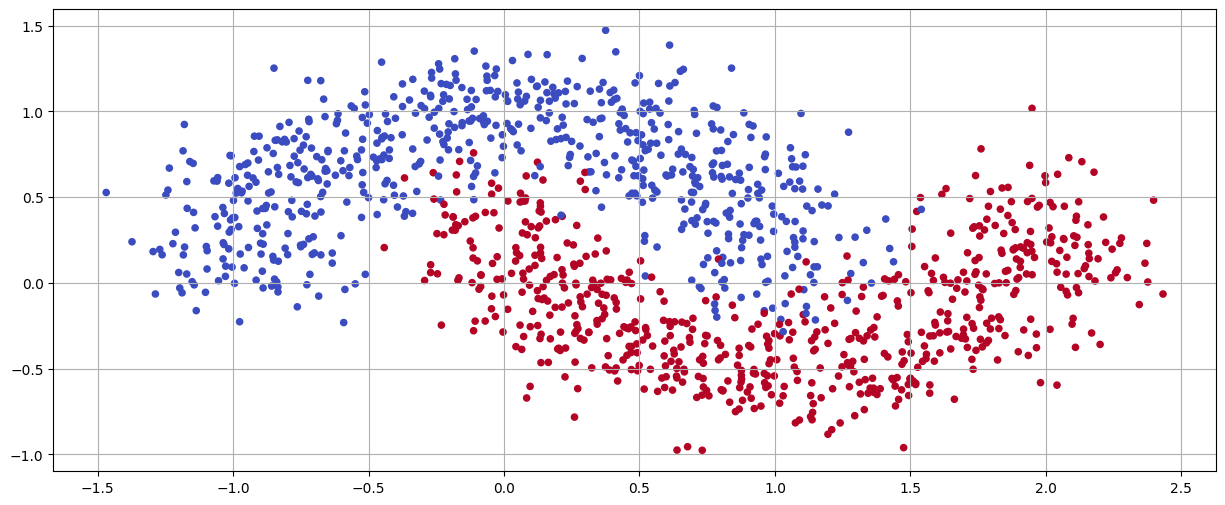

In [7]:
# Plot the data
plt.scatter(X[:,0], X[:,1], s=20, c=y, cmap=CMAP)

plt.grid()

In [8]:
# Make it multi-class data

y = pd.get_dummies(y).to_numpy()
y[:5]

array([[False,  True],
       [ True, False],
       [False,  True],
       [False,  True],
       [False,  True]])

In [9]:
#  Split the data in training and test sets to measure performance of the model.
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    stratify=np.argmax(y, axis=1),
                                                    test_size=0.2, 
                                                    random_state=RANDOM_STATE )

print (X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1024, 2) (1024, 2) (256, 2) (256, 2)


# Neural Network

## Softmax Function for output layer

In [10]:
def fn_softmax(z : np.ndarray) -> np.ndarray:
    '''
        Args:
           z : array, Aggregated values 
       Return:
           probs. of each class
        NOTE: Subtract max for numerical stability.
        This prevents overflow when z has large values.
    '''
    # Subtract max for numerical stability
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    
    exp_sc = np.exp(z_shifted)
    
    return exp_sc / np.sum(exp_sc, axis=1, keepdims=True)

## Activation Function for other layers

In [11]:
def fn_activ(z: np.ndarray) -> np.ndarray:
    
    '''
        Args:
           z : array, Aggregated values 
       Return:
           Activations for each z
    '''

    return np.tanh(z)

def fn_activ_prime(z: np.ndarray) -> np.ndarray:
    '''
        Args:
           z : array, Aggregated values 
       Return:
           Derivative, for each z
    '''

    return 1.0 - np.tanh(z)**2

## Multiple hidden layers

<p style="font-family: Arial; font-size:1.2em"> 
    Moving over to multilayer network. Our data has <strong>two</strong> features. Hence size of input layer will also be two. 
    NOTE: Here we use 2 outputs + softmax for consistency with multi-class formulation. Let's consider following hidden layers:</p>
<table style="font-family: Arial; font-size:1.2em;">
    <tr>
        <th>#</th>
        <th>Layer Number</th>
        <th>Nodes </th>
        <th>Activation </th>
    </tr>
    <tr>
        <td>1</td>
        <td>Input Layer</td>
        <td>2</td>
        <td>tanh</td>
    </tr>
    <tr>
        <td>2</td>
        <td>Hidden Layer 1</td>
        <td>5</td>
        <td>tanh</td>
    </tr>
    <tr>
        <td>3</td>
        <td>Hidden Layer 2</td>
        <td>5</td>
        <td>tanh</td>
    </tr>
    <tr>
        <td>4</td>
        <td>Hidden Layer 3</td>
        <td>4</td>
        <td>tanh</td>
    </tr>
    <tr>
        <td>5</td>
        <td>Hidden Layer 4</td>
        <td>3</td>
        <td>tanh</td>
    </tr>
    <tr>
        <td>6</td>
        <td>Layer 5 (Output)</td>
        <td>2</td>
        <td>softmax</td>
    </tr>
</table>

<img src='../../images/dnn_nb_s06_fig3.jpg' style='width: 800px' alt = 'dnn_nb_s06_fig3.png'/>

## Loss Function

We need to minimize the error by adjusting ($Ws, bs$). We call the function that measures our error the <b>loss function</b>. A common choice with the softmax output is the cross-entropy loss. The loss for predictions $\hat{y}$ with respect to the true labels $y$ is given by:

$
\begin{aligned}L(\hat{y}_i, y_i) = -\sum_{j=1}^{K} y_{ij} \cdot \log(\hat{y}_{ij})
\end{aligned}
$

For all samples:

$
\begin{aligned}
J(\hat{y}, y) =  -\frac{1}{m}\sum_{i=1}^{m}\sum_{j=1}^{K}[y_{ij}.log(\hat{y}_{ij})]
\end{aligned}
$

We can use gradient descent to find its minimum. For purpose of this Session, let's use it in its simplest form - <b>batch gradient descent with fixed learning rate</b>.

## Forward Propagation

<img src='../../images/dnn_nb_s06_fig4.jpg' style='width: 800px' alt = 'Session 6 Figure 4'/>
<br>
                                                               
$
\begin{aligned}
z^{[l]} & = a^{[l-1]} . W^{[l]} + b^{[l]}\\
a^{[l]} & = \text{g}(z^{[l]})\text{ for hidden layers} \\
a^{[l]} & = \mathrm{softmax}(z^{[l]})\text{ for output layer}  \\
\end{aligned}
$

## Loss function

In [12]:
def fn_calculate_loss(model : dict, X: np.ndarray, y: np.ndarray) -> np.float64:
    
    # Extract Weights and biases from the model
    W1, W2, W3, W4, W5 = model['W1'], model['W2'], model['W3'], model['W4'], model['W5']
    b1, b2, b3, b4, b5 = model['b1'], model['b2'], model['b3'], model['b4'], model['b5']
    
    # number of examples
    m = X.shape[0]
    
    #***********************************
    # Layer 1
    z1 = X.dot(W1) + b1  # Aggregation
    a1 = fn_activ(z1)     # Activation

    # Layer 2
    z2 = a1.dot(W2) + b2 # Aggregation
    a2 = fn_activ(z2)     # Activation

    # Layer 3
    z3 = a2.dot(W3) + b3 # Aggregation
    a3 = fn_activ(z3)     # Activation

    # Layer 4
    z4 = a3.dot(W4) + b4 # Aggregation
    a4 = fn_activ(z4)     # Activation

    # Layer 5
    z5 = a4.dot(W5) + b5 # Aggregation
    a5 = fn_softmax(z5)  # softmax activation

    eps = EPSILON
    a5 = np.clip(a5, eps, 1 - eps)
    #***********************************
    
    # Calculating the loss
    data_loss = -np.sum(y * np.log(a5)) 

    return 1./m * data_loss

## Predict Function
<p style="font-family: Arial; font-size:1.2em;">
For predictions, we will simply be using the forward propagation. No need to iterate or calculate the back propagation for supervised learning.
</p>

In [13]:
def fn_predict(model : dict, X: np.ndarray) -> np.ndarray:
    
    # Extract Weights and biases from the model
    W1, W2, W3, W4, W5 = model['W1'], model['W2'], model['W3'], model['W4'], model['W5']
    b1, b2, b3, b4, b5 = model['b1'], model['b2'], model['b3'], model['b4'], model['b5']
    
    # Layer 1
    z1 = X.dot(W1) + b1  # Aggregation
    a1 = fn_activ(z1)     # Activation

    # Layer 2
    z2 = a1.dot(W2) + b2 # Aggregation
    a2 = fn_activ(z2)     # Activation

    # Layer 3
    z3 = a2.dot(W3) + b3 # Aggregation
    a3 = fn_activ(z3)     # Activation

    # Layer 4
    z4 = a3.dot(W4) + b4 # Aggregation
    a4 = fn_activ(z4)     # Activation

    # Layer 5
    z5 = a4.dot(W5) + b5 # Aggregation
    a5 = fn_softmax(z5)  # softmax activation
    
    return np.argmax(a5, axis = 1)

## Backpropagation
#### For last layer
$
\begin{aligned}
\partial{z^{[L]}}  & = a^{[L]} - y \\
\partial{W^{[L]}}  & = \frac{1}{m} a^{[L-1]T}\circ \partial{z^{[L]}} \\
\partial{b^{[L]}}  & = \frac{1}{m} \mathrm{np.sum}(\partial{z^{[L]}}, axis = 0, keepdims = True) \\
\end{aligned}
$

#### For any other layer
$
\begin{aligned}
\partial{a^{[l]}}  & = \partial{z^{[l+1]}} . \partial{W^{[l+1]T}}\\
\partial{z^{[l]}}  & = \partial{a^{[l]}} * ( 1-tanh(z^{[l]})^2)\\
\partial{W^{[l]}}  & = \frac{1}{m} a^{[l-1]T}\circ \partial{z^{[l]}} \\
\partial{b^{[l]}}  & = \frac{1}{m} \mathrm{np.sum}(\partial{z^{[l]}}, axis = 0, keepdims = True) \\
\\
\end{aligned}
$

## Build Model

**NOTE:** While coding:
- $W_1 \equiv W^{[1]},\; W_2 \equiv W^{[2]},\; \ldots$ (layer-wise notation)
- $dw1 \equiv \frac{\partial{J}}{\partial{W^{[1]}}}; dw2 \equiv \frac{\partial{J}}{\partial{W^{[2]}}} $ and so on

In [14]:
def build_model(param: dict,
                X : np.ndarray, 
                y : np.ndarray, 
                epochs: np.int64 = EPOCHS, 
                alpha: np.float64 = ALPHA) -> dict:
    
    m = X.shape[0] # number of rows
    nn_output_dim = y.shape[1] # output layer dimensionality
    
    # Initialize the weights and biases to random values. We need to learn these.
    W1 = rng.standard_normal((param['nn_hdim'][0], param['nn_hdim'][1])) / np.sqrt(param['nn_hdim'][0])
    b1 = np.zeros((1, param['nn_hdim'][1]))
    
    W2 = rng.standard_normal((param['nn_hdim'][1], param['nn_hdim'][2])) / np.sqrt(param['nn_hdim'][1])
    b2 = np.zeros((1, param['nn_hdim'][2]))
    
    W3 = rng.standard_normal((param['nn_hdim'][2], param['nn_hdim'][3])) / np.sqrt(param['nn_hdim'][2])
    b3 = np.zeros((1, param['nn_hdim'][3]))
    
    W4 = rng.standard_normal((param['nn_hdim'][3], param['nn_hdim'][4])) / np.sqrt(param['nn_hdim'][3])
    b4 = np.zeros((1, param['nn_hdim'][4]))
   
    W5 = rng.standard_normal((param['nn_hdim'][4], nn_output_dim)) / np.sqrt(param['nn_hdim'][4])
    b5 = np.zeros((1, nn_output_dim))
    
    # lists to collect losses
    curr_loss = 0
    epoch, loss = [],[]
    
    for i in range(0, epochs):
        
        #### Forward ------------------------------
        # Layer 1
        z1 = X.dot(W1) + b1  # aggregation
        a1 = fn_activ(z1)     # activation
        
        # Layer 2
        z2 = a1.dot(W2) + b2 # aggregation
        a2 = fn_activ(z2)     # activation
        
        # Layer 3
        z3 = a2.dot(W3) + b3 # aggregation 
        a3 = fn_activ(z3)     # activation
        
        # Layer 4
        z4 = a3.dot(W4) + b4 # aggregation 
        a4 = fn_activ(z4)     # activation
        
        # Layer 5
        z5 = a4.dot(W5) + b5 # aggregation
        a5 = fn_softmax(z5)  # activation

        
        ### Back Prop ------------------------------
        dz5 = a5- y
        
        # Layer 5
        dW5 = (a4.T).dot(dz5) 
        db5 = np.sum(dz5, axis=0, keepdims=True) # db5 is vertical sum of dz5
        da4 = dz5.dot(W5.T)
        
        #Layer 4
        dz4 = da4 * fn_activ_prime(z4)        
        dW4 = (a3.T).dot(dz4)        
        db4 = np.sum(dz4, axis=0, keepdims=True)
        da3 = dz4.dot(W4.T)
        
        #Layer 3
        dz3 = da3 * fn_activ_prime(z3)
        dW3 = (a2.T).dot(dz3)
        db3 = np.sum(dz3, axis=0, keepdims=True)
        da2 = dz3.dot(W3.T)
        
        #Layer 2
        dz2 = da2 * fn_activ_prime(z2)        
        dW2 = (a1.T).dot(dz2)        
        db2 = np.sum(dz2, axis=0, keepdims=True)
        da1= dz2.dot(W2.T)
        
        #Layer 1
        dz1 = da1 * fn_activ_prime(z1)
        dW1 = (X.T).dot(dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)
        
        
        # Weights update
        W1 += -alpha * dW1 /m
        b1 += -alpha * db1 /m
        
        W2 += -alpha * dW2 /m
        b2 += -alpha * db2 /m
        
        W3 += -alpha * dW3 /m
        b3 += -alpha * db3 /m
        
        W4 += -alpha * dW4 /m
        b4 += -alpha * db4 /m
        
        W5 += -alpha * dW5 /m
        b5 += -alpha * db5 /m
        
        model = { 
            'W1': W1, 'b1': b1,
            'W2': W2, 'b2': b2,
            'W3': W3, 'b3': b3,
            'W4': W4, 'b4': b4,
            'W5': W5, 'b5': b5}
        
        if i % 10 == 0:
            curr_loss = fn_calculate_loss (model, X, y)
            loss.append(curr_loss)
            epoch.append(i)
            
            # Print the loss.
            if i % 1000 == 0:
                print("Loss after iteration %i: %f" %(i, curr_loss))
    
    loss_hist['epoch'] = epoch
    loss_hist['loss'] = loss
    
    return model

In [15]:
# assemble all parameters in a dictionary object
layer_param = {}
layer_param['nn_hdim'] = [X_train.shape[1],5,5,4,3] #We gradually reduce dimensionality to force feature abstraction
loss_hist = {}

In [16]:
alpha = ALPHA
epochs = EPOCHS
model = build_model(layer_param, X_train, y_train, epochs, alpha ) 

Loss after iteration 0: 0.681798
Loss after iteration 1000: 0.094468
Loss after iteration 2000: 0.088999


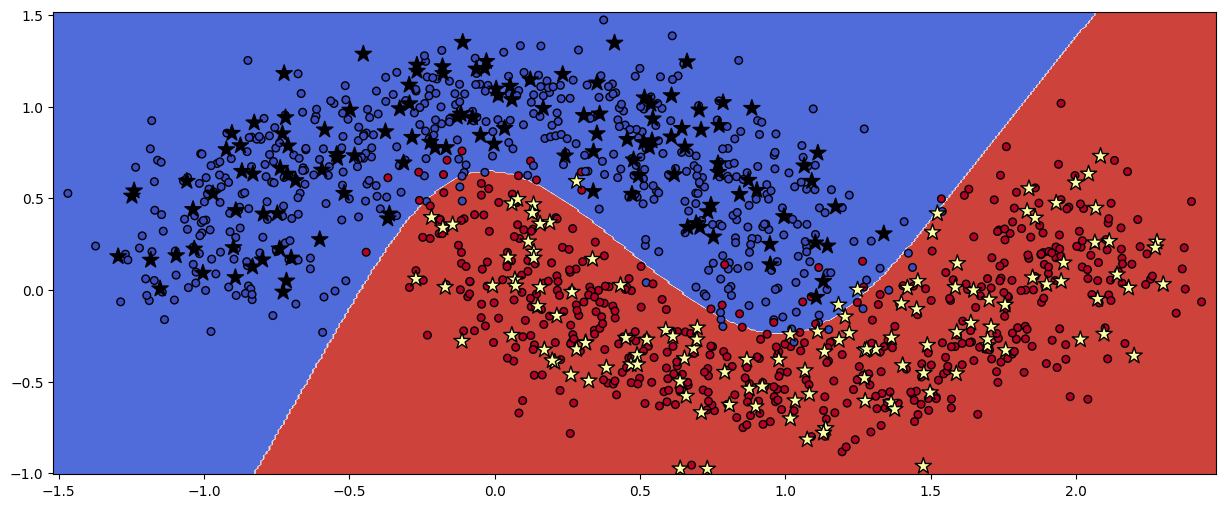

In [17]:
fn_plot_decision_boundary(model, X_train, y_train, X_test, y_test) # plot decision boundary for this plot

In [18]:
y_pred = fn_predict(model, X_train)
print('Accuracy score on Train Data :', accuracy_score(np.argmax(y_train, axis = 1), y_pred))

Accuracy score on Train Data : 0.9619140625


In [19]:
print(classification_report(np.argmax(y_train, axis = 1), y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       512
           1       0.97      0.95      0.96       512

    accuracy                           0.96      1024
   macro avg       0.96      0.96      0.96      1024
weighted avg       0.96      0.96      0.96      1024



In [20]:
y_pred = fn_predict(model, X_test)

print('Accuracy score on Test Data :', accuracy_score(np.argmax(y_test, axis = 1), y_pred))

Accuracy score on Test Data : 0.98828125


In [21]:
print(classification_report(np.argmax(y_test, axis = 1), y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       128
           1       1.00      0.98      0.99       128

    accuracy                           0.99       256
   macro avg       0.99      0.99      0.99       256
weighted avg       0.99      0.99      0.99       256



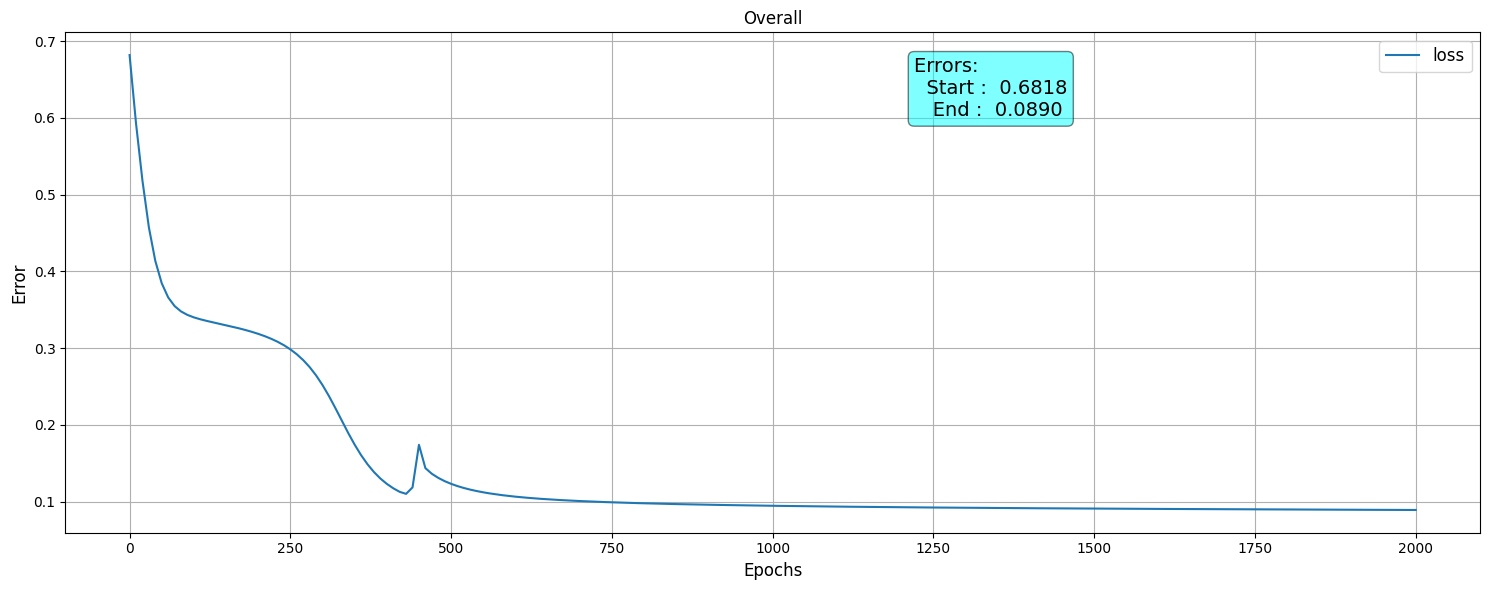

In [22]:
loss_df = pd.DataFrame(loss_hist)

fig, ax = plt.subplots()

loss_df.plot(x = 'epoch', y = 'loss', ax = ax)
loss = loss_df['loss'].values

# little beautification
txtstr = "Errors: \n  Start : {:7.4f}\n   End : {:7.4f}".format(loss[0],loss[-1]) #text to plot

# properties  matplotlib.patch.Patch 
props = dict(boxstyle='round', facecolor='cyan', alpha=0.5)

# place a text box in upper left in axes coords

ax.text(0.6, 0.95, txtstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

ax.set_xlabel("Epochs")
ax.set_ylabel("Error")
ax.set_title('Overall')
ax.grid();

plt.tight_layout()